# 03 — Classical baselines (M1–M3)

Methodology §3.9.1 (features), §3.10.1–3.10.3 (models), §3.11.2 (tuning), §3.12 (metrics).

Three classical models on TF-IDF features, each evaluated on every test condition.
They are the reference the transformers (notebook 04) have to beat.

**Code:** `src/features_tfidf.py`, `src/baselines.py`, `src/evaluate.py`
**Outputs:** models in `models/classical/*.joblib`, feature matrices in
`data/processed/features/` (`X_*.npz`, `y_*.npy`), figures in `results/figures/`,
tables in `results/tables/`.

In [1]:
import os, sys, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":        # run from the project root
    os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.dpi"] = 80           # on-screen size only; saved PNGs are 300 dpi
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("working directory:", Path.cwd().name)

working directory: sentinelprompt


### Test conditions

| ID | Test set | Rows | What it asks |
|---|---|---|---|
| **E1** | Test-Clean | 100 | How good is the model on unseen prompts like the training data? |
| **E2** | Test-Paraphrase | E1 rows reworded | Does the same attack, said differently, still get caught? |
| **E3** | Test-Obfuscated | 1,900 | Does it survive leetspeak, spacing, homoglyphs, zero-width, casing, typos, base64? |
| **E4** | Bangla–English (D4) | 900 | Does an English-trained model work on Bangla and code-mixed Bangla? |
| **E5** | Lakera | 1,000 | Does it catch attacks from a source it never saw? (all injections) |
| **FP** | PromptBench | 4,150 | Does it wrongly flag harmless task prompts? (all safe) |
| **E5x** | Lakera + PromptBench | 5,150 | E5 and FP pooled, so ROC-AUC and PR-AUC are defined |

E5 and FP each hold a single class. On those, macro-F1, ROC-AUC and PR-AUC are
undefined and shown as `NaN` on purpose; accuracy there equals recall (E5) or
specificity (FP). E5x pools them so the threshold-free metrics can be computed.

## Load the data and check the protocol

The guards stop the run if the training data breaks the design: Lakera (E5) or the
Bangla–English set (E4) in training, any non-original variant in training, or one
near-duplicate group on both sides of a split.

In [2]:
import evaluate as ev
import baselines as bl
tr, va = bl.load_data()
print(f"train {len(tr)} rows ({tr.label.mean():.1%} injection) | validation {len(va)} rows")
print("all protocol guards passed")
conditions = ev.load_conditions()
display(pd.DataFrame({c: [len(d), int(d.label.sum())] for c, d in conditions.items()},
                     index=["rows", "injections"]).T)

train 462 rows (41.8% injection) | validation 100 rows
all protocol guards passed


,rows,injections
E1_clean,100,34
E2_paraphrase,80,41
E3_obfuscated,1900,646
E4_codemix,900,450
E5_crossdataset,1000,1000
FP_promptbench,4150,0
E5x_pooled,5150,1000


## Features — TF-IDF (§3.9.1)

Each prompt becomes a sparse vector. **TF-IDF** weights a term highly when it is frequent in
this prompt but rare across all prompts. Two blocks are joined:

| Block | Range | Why |
|---|---|---|
| word n-grams | 1–3 | multi-word attack phrases like *"ignore previous instructions"* |
| character n-grams | 3–5 | survive obfuscation (*1gn0r3*) that breaks whole words |

Settings: `min_df=2`, `max_df=0.95`, `max_features=50,000` per block, sublinear TF, L2 norm,
lowercase. The vectorizer is fitted on **training data only**. Inside grid search it is re-fitted
in every fold, so no vocabulary from a validation fold leaks into tuning.

In [3]:
shapes = bl.save_features(tr, va, conditions)
display(pd.DataFrame(shapes, index=["rows", "features"]).T)
print("saved: data/processed/features/X_*.npz, y_*.npy and models/classical/tfidf_vectorizer.joblib")

,rows,features
train,462,15204
val,100,15204
E1_clean,100,15204
E2_paraphrase,80,15204
E3_obfuscated,1900,15204
E4_codemix,900,15204
E5_crossdataset,1000,15204
FP_promptbench,4150,15204
E5x_pooled,5150,15204


saved: data/processed/features/X_*.npz, y_*.npy and models/classical/tfidf_vectorizer.joblib


### The >97% accuracy guard

If any model scores above **97% accuracy** on a test condition, the evaluation code
prints a warning and runs a leakage check on that test set against the training set:

* **shared groups** — does any test row belong to a near-duplicate group seen in training?
* **exact text overlap** — is the identical prompt in training?
* **near duplicates** — is a prompt with ≥ 80% character-shingle overlap in training?

Then it says which explanation fits: leakage, a single-class test set (where accuracy
is just recall or specificity), or neither.

In [4]:
runs = {}

## M1 — TF-IDF + Logistic Regression

**What it is.** A linear classifier. Every feature (a word or character n-gram) gets a
weight; the weighted sum is turned into a probability between 0 and 1.

**How it works.** For a prompt with feature vector *x*: score *z = w·x + b*, then
*P(injection) = 1 / (1 + e^(−z))* (the sigmoid). Training minimises log-loss plus a penalty
on large weights (L2 or L1), which stops the model memorising rare n-grams.

**Why we chose it.** Fast, stable, and interpretable — each n-gram's weight shows which way
it pushes the decision. It is the standard strong baseline for text classification.

**Hyperparameters** (grid search, 5-fold grouped CV, scored on macro-F1):

| Hyperparameter | Values searched | Meaning |
|---|---|---|
| `C` | 0.01, 0.1, 1, 10, 100 | inverse regularisation strength (small = simpler model) |
| penalty | L1, L2 | L1 can switch features off; L2 only shrinks them |
| `class_weight` | None, balanced | whether to up-weight the smaller class |
| solver | liblinear | |
| threshold | tuned on validation | the probability cut-off for "injection" |

In [5]:
run = bl.run_one("logreg", tr, va, conditions)
runs["logreg"] = run
display(ev.tidy(run["metrics"])[["condition", "n", "threshold", "accuracy", "precision", "recall",
    "specificity", "macro_f1", "mcc", "roc_auc", "pr_auc", "note"]])

logreg: best CV macro-F1 0.9279 with {'clf__C': 100, 'clf__class_weight': None, 'clf__l1_ratio': 0}  (20 combinations x 5 folds, 3.2s)
logreg: threshold tuned on validation = 0.7068 (val macro-F1 0.9439)


,condition,n,threshold,accuracy,precision,recall,specificity,macro_f1,mcc,roc_auc,pr_auc,note
0,E1_clean,100,0.7068,0.9200,0.8824,0.8824,0.9394,0.9109,0.8217,0.9728,0.9386,NaN
1,E2_paraphrase,80,0.7068,0.8500,0.9143,0.7805,0.9231,0.8496,0.7089,0.9500,0.9581,NaN
2,E3_obfuscated,1900,0.7068,0.8763,0.8166,0.8204,0.9051,0.8624,0.7247,0.9544,0.9144,NaN
3,E4_codemix,900,0.7068,0.6722,0.9101,0.3822,0.9622,0.6421,0.4228,0.7247,0.7667,NaN
4,E5_crossdataset,1000,0.7068,0.9580,1.0000,0.9580,NaN,NaN,NaN,NaN,NaN,all-injection set: accuracy = recall
5,FP_promptbench,4150,0.7068,0.2137,0.0000,NaN,0.2137,NaN,NaN,NaN,NaN,all-safe set: accuracy = specificity
6,E5x_pooled,5150,0.7068,0.3583,0.2270,0.9580,0.2137,0.3581,0.1767,0.8104,0.6365,NaN


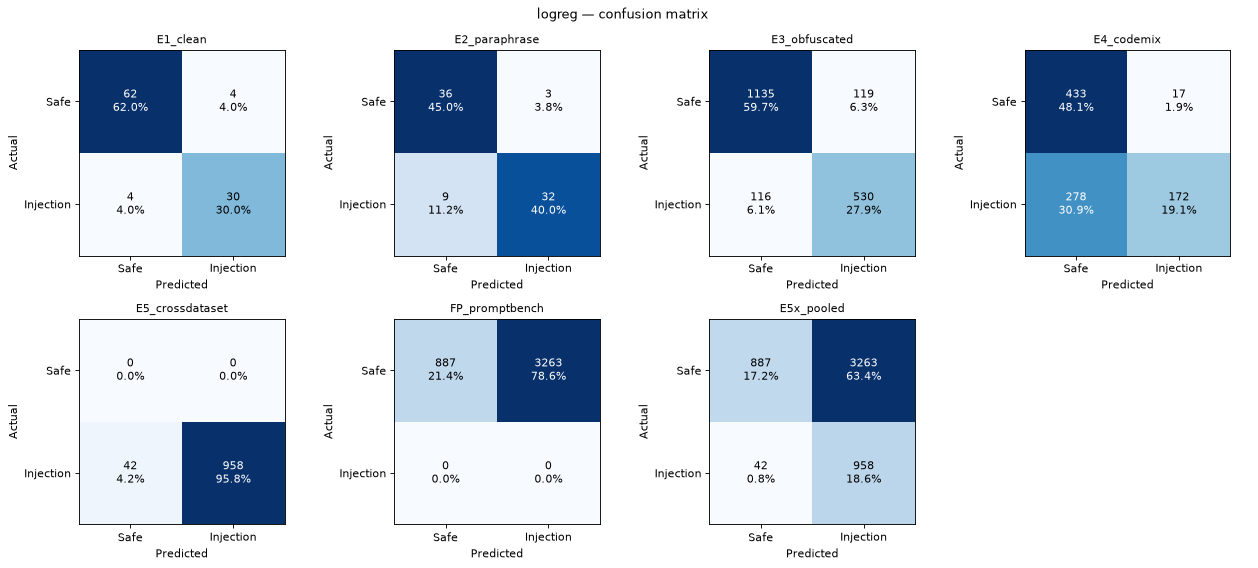

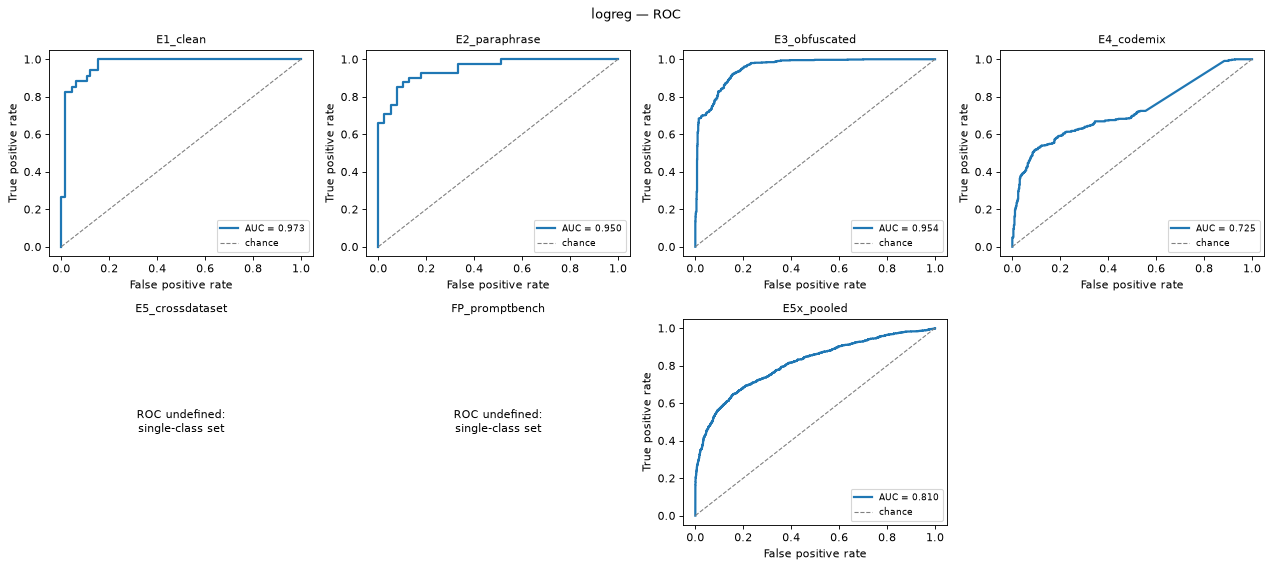

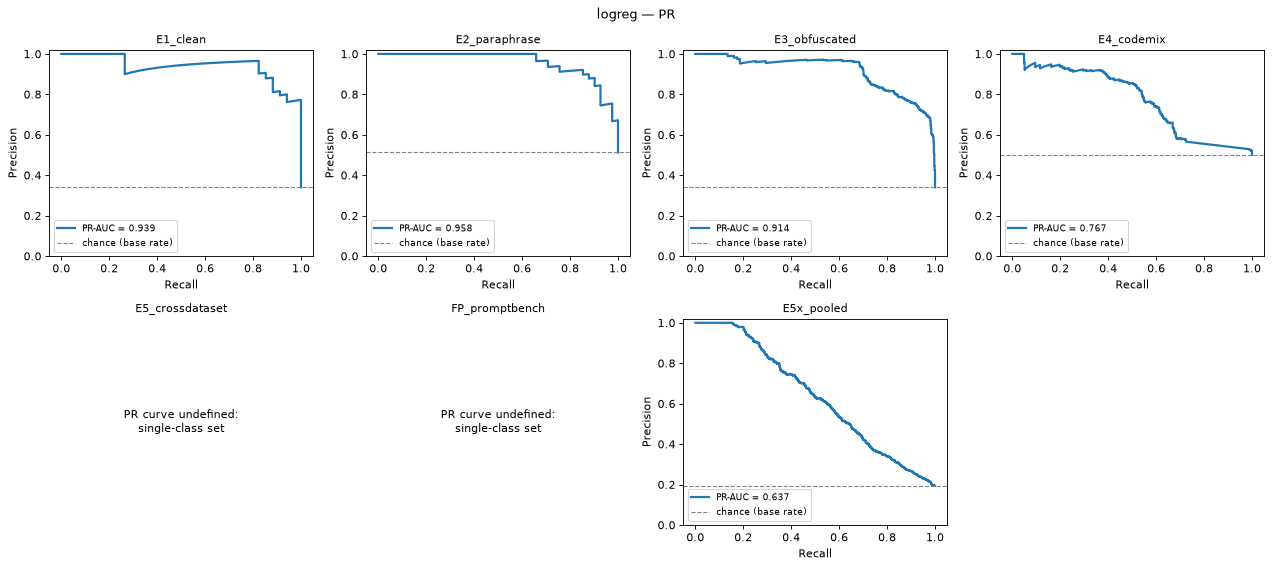

In [6]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(runs["logreg"], kind); plt.show()

In [7]:
print("Classification report on E1 (Test-Clean):")
r = runs["logreg"]["reports"]
display(r[r.condition == "E1_clean"].drop(columns=["model", "condition"]).reset_index(drop=True))

Classification report on E1 (Test-Clean):


,class,precision,recall,f1,support
0,Safe,0.9394,0.9394,0.9394,66
1,Injection,0.8824,0.8824,0.8824,34
2,macro avg,0.9109,0.9109,0.9109,100
3,weighted avg,0.9200,0.9200,0.9200,100


## M2 — TF-IDF + Multinomial Naive Bayes

**What it is.** A probabilistic classifier based on Bayes' theorem.

**How it works.** It estimates how often each term appears in each class, then picks the
class that makes the observed terms most likely: *ĉ = argmax log P(c) + Σ log P(tᵢ | c)*.
It assumes terms are independent of each other given the class (the "naive" part) — false
in reality ("previous" and "instructions" travel together), but it still works well on text.
**Smoothing (α)** adds a small count to every term so an unseen term does not zero out a class.

**Why we chose it.** Extremely fast and a classic sanity-check baseline for sparse text.
If a complex model cannot beat Naive Bayes, something is wrong.

**Hyperparameters** (grid search, 5-fold grouped CV, macro-F1):

| Hyperparameter | Values searched | Meaning |
|---|---|---|
| `alpha` | 0.01, 0.1, 0.5, 1.0 | smoothing strength (1.0 = Laplace) |
| threshold | tuned on validation | probability cut-off |

scikit-learn's MultinomialNB has no `class_weight`; the tuned threshold compensates for imbalance.

In [8]:
run = bl.run_one("naive_bayes", tr, va, conditions)
runs["naive_bayes"] = run
display(ev.tidy(run["metrics"])[["condition", "n", "threshold", "accuracy", "precision", "recall",
    "specificity", "macro_f1", "mcc", "roc_auc", "pr_auc", "note"]])

naive_bayes: best CV macro-F1 0.8705 with {'clf__alpha': 0.1}  (4 combinations x 5 folds, 0.3s)
naive_bayes: threshold tuned on validation = 0.8513 (val macro-F1 0.8990)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Unusually high accuracy is a classic symptom of train/test leakage.
Leakage check:
   shared_groups              0
   exact_text_overlap         0
   near_duplicates_in_train   0
   test_rows                  1000
   test_is_single_class       True
-> No leakage. The set holds a single class, so accuracy equals recall (or specificity) and says nothing about the other class.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



,condition,n,threshold,accuracy,precision,recall,specificity,macro_f1,mcc,roc_auc,pr_auc,note
0,E1_clean,100,0.8513,0.8800,0.8235,0.8235,0.9091,0.8663,0.7326,0.9340,0.9184,NaN
1,E2_paraphrase,80,0.8513,0.8875,1.0000,0.7805,1.0000,0.8866,0.7963,0.9043,0.9350,NaN
2,E3_obfuscated,1900,0.8513,0.8616,0.7837,0.8189,0.8836,0.8474,0.6953,0.9032,0.8295,NaN
3,E4_codemix,900,0.8513,0.7211,0.7935,0.5978,0.8444,0.7168,0.4563,0.7865,0.8004,NaN
4,E5_crossdataset,1000,0.8513,0.9920,1.0000,0.9920,NaN,NaN,NaN,NaN,NaN,all-injection set: accuracy = recall
5,FP_promptbench,4150,0.8513,0.0361,0.0000,NaN,0.0361,NaN,NaN,NaN,NaN,all-safe set: accuracy = specificity
6,E5x_pooled,5150,0.8513,0.2217,0.1987,0.9920,0.0361,0.2004,0.0646,0.8665,0.7466,NaN


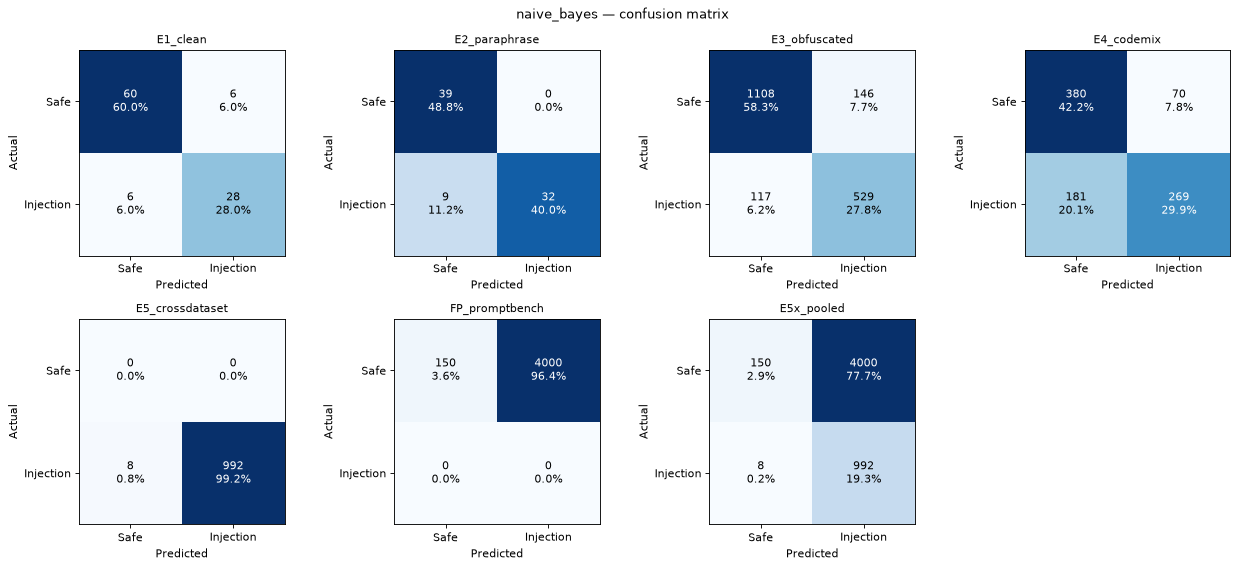

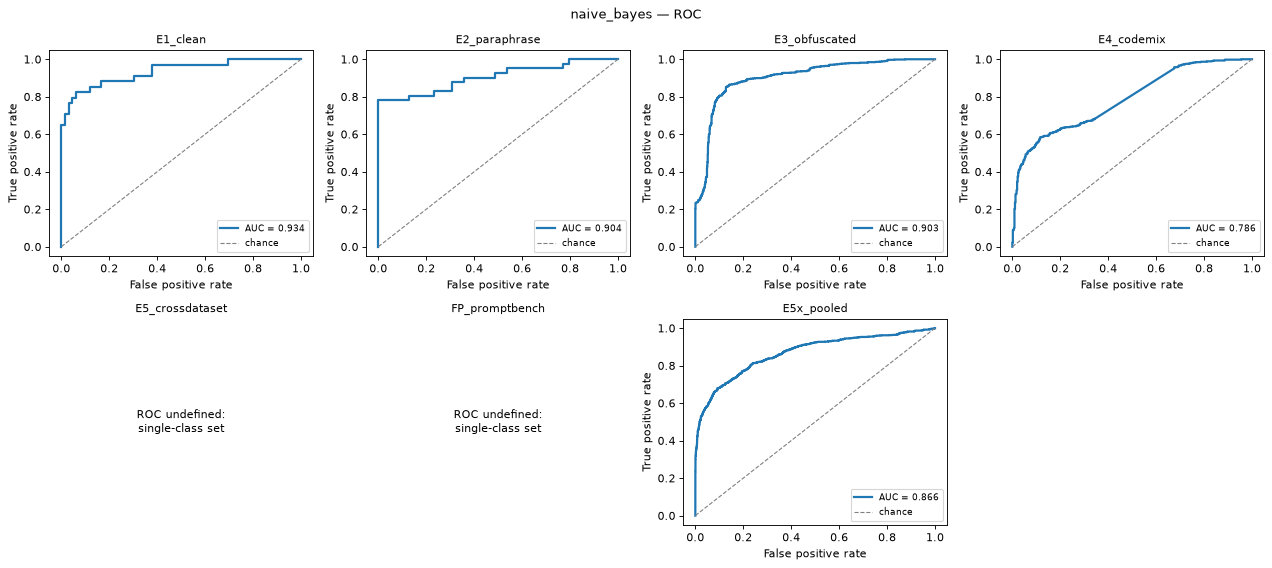

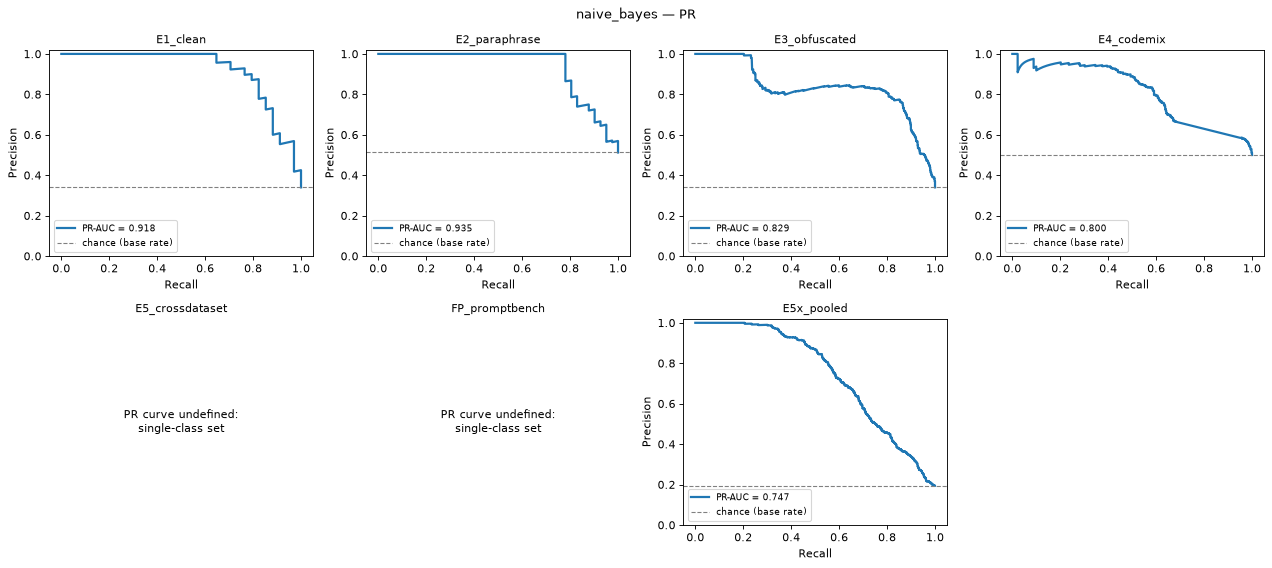

In [9]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(runs["naive_bayes"], kind); plt.show()

In [10]:
print("Classification report on E1 (Test-Clean):")
r = runs["naive_bayes"]["reports"]
display(r[r.condition == "E1_clean"].drop(columns=["model", "condition"]).reset_index(drop=True))

Classification report on E1 (Test-Clean):


,class,precision,recall,f1,support
0,Safe,0.9091,0.9091,0.9091,66
1,Injection,0.8235,0.8235,0.8235,34
2,macro avg,0.8663,0.8663,0.8663,100
3,weighted avg,0.8800,0.8800,0.8800,100


## M3 — TF-IDF + Linear SVM

**What it is.** A Support Vector Machine with a linear kernel.

**How it works.** It finds the straight boundary (hyperplane) between the classes with the
**widest margin** — the largest gap to the nearest training points (the *support vectors*).
Training minimises hinge loss plus a penalty on weight size. A wide margin tends to generalise
better. Its output is a signed distance from the boundary, not a probability; we use that
distance as the score for ROC and PR curves.

**Why we chose it.** Historically one of the strongest classifiers for high-dimensional
sparse text. A linear kernel is enough because TF-IDF text is close to linearly separable;
an RBF kernel would add cost without benefit.

**Hyperparameters** (grid search, 5-fold grouped CV, macro-F1):

| Hyperparameter | Values searched | Meaning |
|---|---|---|
| `C` | 0.1, 1, 10 | trade-off between a wide margin and fitting every training point |
| `class_weight` | balanced (fixed) | up-weights the smaller class |
| threshold | tuned on validation | cut-off on the decision value |

In [11]:
run = bl.run_one("linear_svm", tr, va, conditions)
runs["linear_svm"] = run
display(ev.tidy(run["metrics"])[["condition", "n", "threshold", "accuracy", "precision", "recall",
    "specificity", "macro_f1", "mcc", "roc_auc", "pr_auc", "note"]])

linear_svm: best CV macro-F1 0.9327 with {'clf__C': 10}  (3 combinations x 5 folds, 0.3s)
linear_svm: threshold tuned on validation = 0.2830 (val macro-F1 0.9554)


,condition,n,threshold,accuracy,precision,recall,specificity,macro_f1,mcc,roc_auc,pr_auc,note
0,E1_clean,100,0.2830,0.9000,0.8529,0.8529,0.9242,0.8886,0.7772,0.9715,0.9391,NaN
1,E2_paraphrase,80,0.2830,0.8500,0.9143,0.7805,0.9231,0.8496,0.7089,0.9500,0.9569,NaN
2,E3_obfuscated,1900,0.2830,0.8700,0.8132,0.8019,0.9051,0.8547,0.7094,0.9518,0.9107,NaN
3,E4_codemix,900,0.2830,0.6489,0.8895,0.3400,0.9578,0.6119,0.3787,0.7137,0.7567,NaN
4,E5_crossdataset,1000,0.2830,0.9340,1.0000,0.9340,NaN,NaN,NaN,NaN,NaN,all-injection set: accuracy = recall
5,FP_promptbench,4150,0.2830,0.3017,0.0000,NaN,0.3017,NaN,NaN,NaN,NaN,all-safe set: accuracy = specificity
6,E5x_pooled,5150,0.2830,0.4245,0.2437,0.9340,0.3017,0.4223,0.2136,0.7911,0.5892,NaN


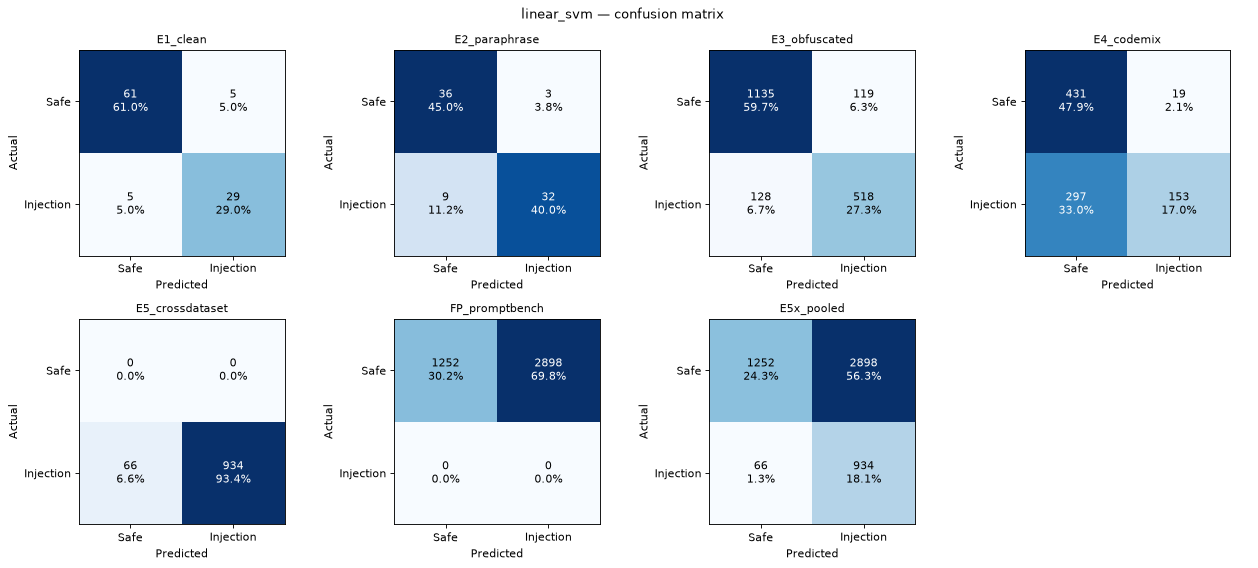

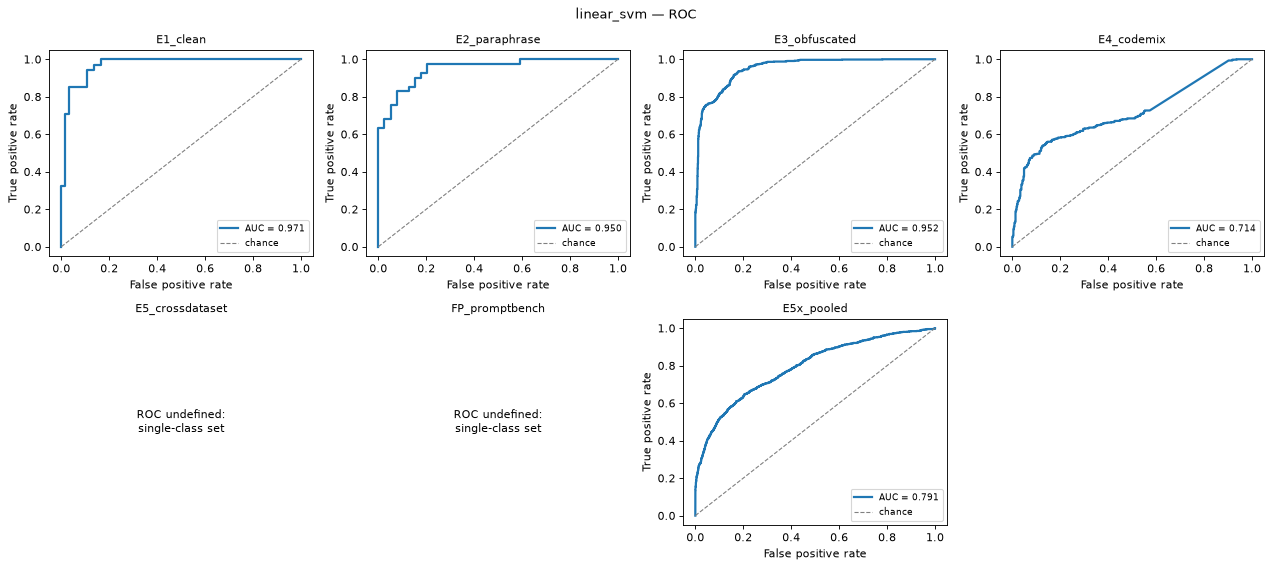

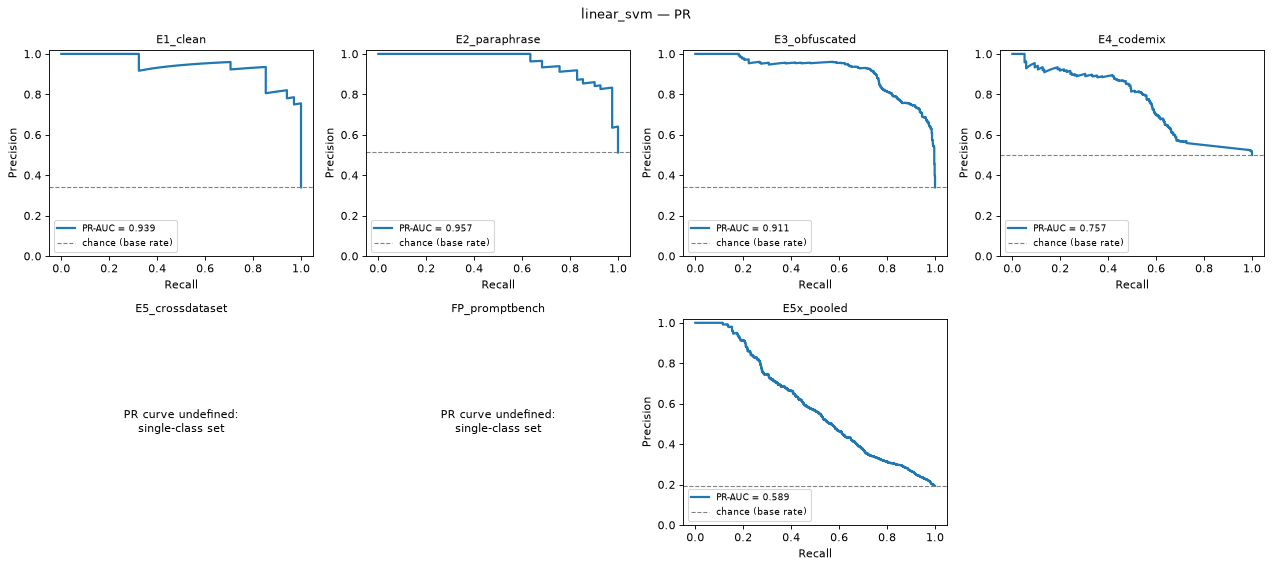

In [12]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(runs["linear_svm"], kind); plt.show()

In [13]:
print("Classification report on E1 (Test-Clean):")
r = runs["linear_svm"]["reports"]
display(r[r.condition == "E1_clean"].drop(columns=["model", "condition"]).reset_index(drop=True))

Classification report on E1 (Test-Clean):


,class,precision,recall,f1,support
0,Safe,0.9242,0.9242,0.9242,66
1,Injection,0.8529,0.8529,0.8529,34
2,macro avg,0.8886,0.8886,0.8886,100
3,weighted avg,0.9000,0.9000,0.9000,100


## Comparison of the three baselines

model,linear_svm,logreg,naive_bayes
condition,,,
E1_clean,0.8886,0.9109,0.8663
E2_paraphrase,0.8496,0.8496,0.8866
E3_obfuscated,0.8547,0.8624,0.8474
E4_codemix,0.6119,0.6421,0.7168
E5_crossdataset,NaN,NaN,NaN
FP_promptbench,NaN,NaN,NaN
E5x_pooled,0.4223,0.3581,0.2004


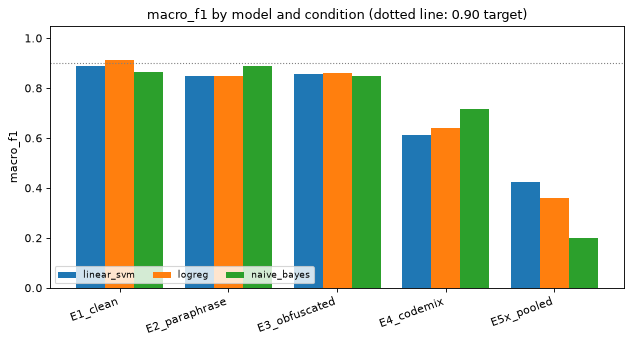

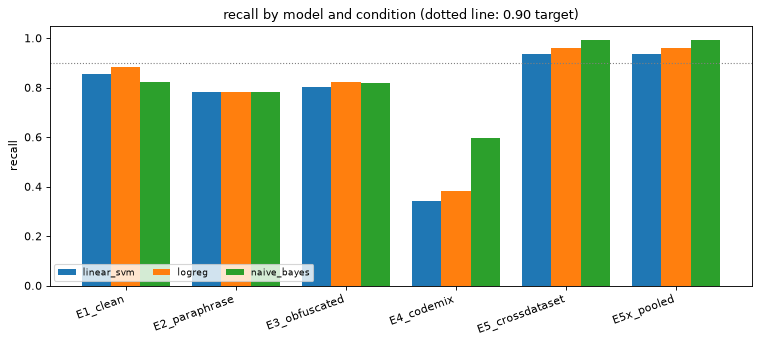

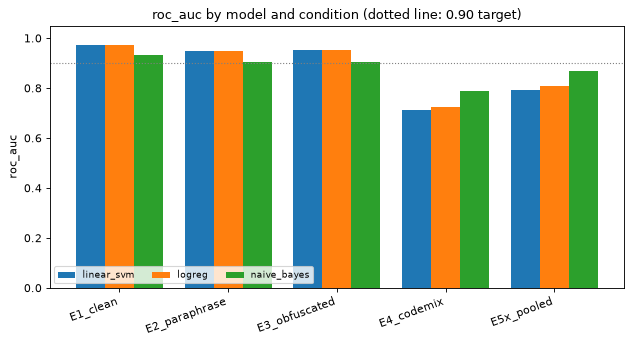

In [14]:
bl.save_all(list(runs.values()))
metrics = ev.tidy(pd.concat([r["metrics"] for r in runs.values()]))
display(metrics.pivot_table(index="condition", columns="model", values="macro_f1")
        .reindex([c for c in ev.CONDITIONS if c in metrics.condition.unique()]))
for m in ["macro_f1", "recall", "roc_auc"]:
    ev.comparison_chart(metrics, m, name=f"baselines_comparison_{m}"); plt.show()

## Tuning results and efficiency (E7)

In [15]:
display(pd.DataFrame([r["meta"] for r in runs.values()]))

,model,best_params,cv_macro_f1,val_macro_f1,threshold,tuning_seconds,ms_per_row,size_mb
0,logreg,"{'clf__C': 100, 'clf__class_weight': None, 'cl...",0.9279,0.9439,0.7068,3.2000,0.0792,0.6700
1,naive_bayes,{'clf__alpha': 0.1},0.8705,0.8990,0.8513,0.3000,0.0779,1.0300
2,linear_svm,{'clf__C': 10},0.9327,0.9554,0.2830,0.3000,0.0791,0.6700


## What the classical models rely on (§3.15.3)

Linear models are fully readable: every feature has one weight.

* **Logistic Regression / Linear SVM** — the largest positive weights push a prompt towards
  *Injection*, the largest negative ones towards *Safe*.
* **Naive Bayes** — the methodology's measure is the log-probability ratio
  log P(term | Injection) − log P(term | Safe): how much more typical a term is of attacks.

Feature names show their block: `word` is a word n-gram, `char` a character n-gram
(character n-grams are padded with spaces at word edges, so `' a '` is the word *a* on its own).

What to look for: **are the top features about how attacks work** (*ignore, instructions,
forget*), **or about what the prompts happen to be about** (a topic, a country, a language)?
The second kind is a shortcut — it predicts the label in this training set without having
anything to do with prompt injection.

Share of total absolute weight carried by each feature block:


,model,word,char
0,logreg,0.3336,0.6664
1,linear_svm,0.3312,0.6688
2,naive_bayes,0.3069,0.6931


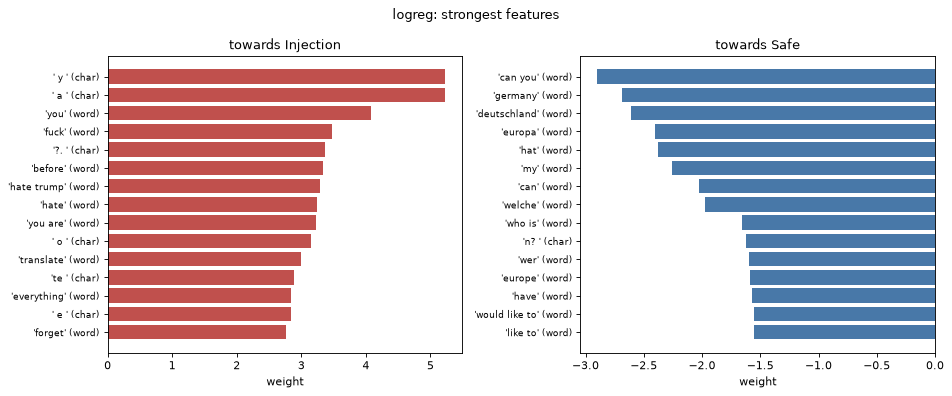

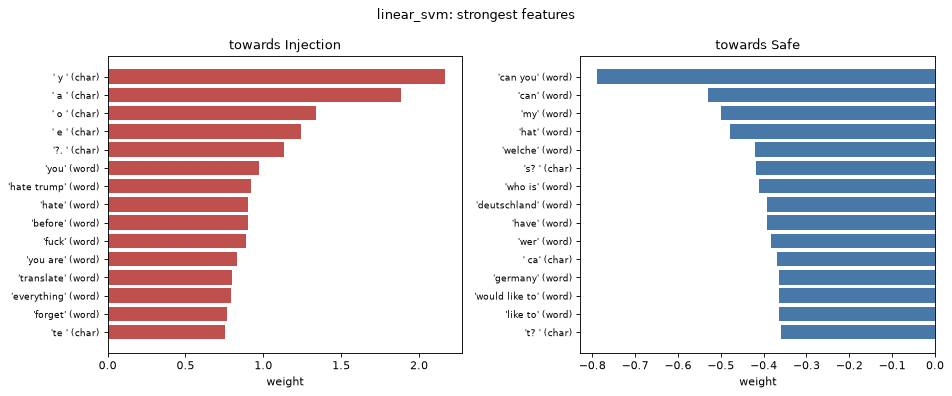

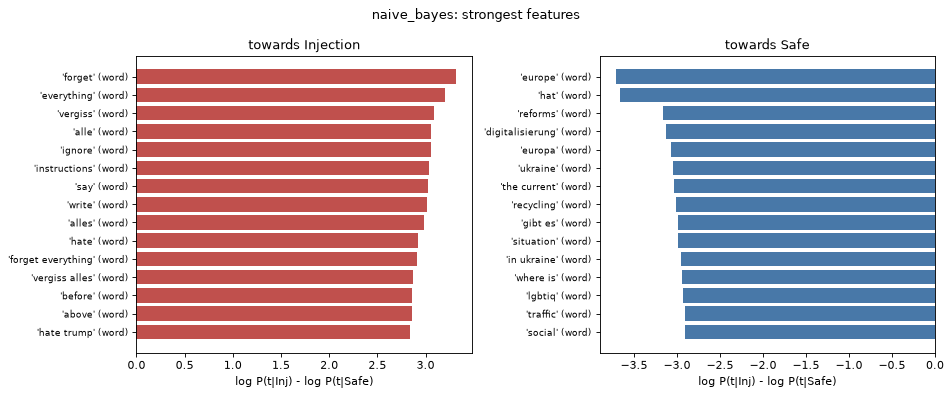

Top 15 per direction:


model            linear_svm                           logreg                       naive_bayes                 
direction towards_injection   towards_safe towards_injection   towards_safe  towards_injection     towards_safe
rank                                                                                                           
1                        y         can you                y         can you             forget           europe
2                        a             can                a         germany         everything              hat
3                        o              my               you    deutschland            vergiss          reforms
4                        e             hat              fuck         europa               alle  digitalisierung
5                       ?.          welche               ?.             hat             ignore           europa
6                       you            s?             before             my       instructions          ukraine
7                hate trump         who is        hate trump            can                say      the current
8                      hate    deutschland              hate         welche              write        recycling
9                    before           have           you are         who is              alles          gibt es
10                     fuck            wer                o             n?                hate        situation
11                  you are             ca         translate            wer  forget everything       in ukraine
12                translate        germany               te          europe      vergiss alles         where is
13               everything  would like to        everything           have             before           lgbtiq
14                   forget        like to                e   would like to              above          traffic
15                      te             t?             forget        like to         hate trump           social

In [16]:
import explain_classical as xc
coef, share = xc.run()
print("Share of total absolute weight carried by each feature block:")
display(share)
for m in ["logreg", "linear_svm", "naive_bayes"]:
    xc.plot(coef, m); plt.show()
print("Top 15 per direction:")
display(coef[coef["rank"] <= 15].pivot_table(index="rank", columns=["model", "direction"],
        values="feature", aggfunc="first"))

## Key findings (computed from the tables above)

In [17]:
def f(m, c, col="macro_f1"):
    v = metrics[(metrics.model == m) & (metrics.condition == c)][col]
    return float(v.iloc[0]) if len(v) else float("nan")
for m in runs:
    print(f"{m:12s} E1 macro-F1 {f(m,'E1_clean'):.3f} | E4 Bangla {f(m,'E4_codemix'):.3f}"
          f" | E5 recall {f(m,'E5_crossdataset','recall'):.3f}"
          f" | FP false-positive rate {1 - f(m,'FP_promptbench','specificity'):.3f}")
print()
print("Read E5 and FP together: a high E5 recall next to a high FP false-positive rate means")
print("the model flags instruction-style text in general, not injections specifically.")
checks = [r["checks"] for r in runs.values() if len(r["checks"])]
if checks:
    print("\n>97% accuracy warnings raised:")
    display(pd.concat(checks)[["model", "condition", "accuracy", "shared_groups",
                               "exact_text_overlap", "near_duplicates_in_train", "test_is_single_class"]])

logreg       E1 macro-F1 0.911 | E4 Bangla 0.642 | E5 recall 0.958 | FP false-positive rate 0.786
naive_bayes  E1 macro-F1 0.866 | E4 Bangla 0.717 | E5 recall 0.992 | FP false-positive rate 0.964
linear_svm   E1 macro-F1 0.889 | E4 Bangla 0.612 | E5 recall 0.934 | FP false-positive rate 0.698

Read E5 and FP together: a high E5 recall next to a high FP false-positive rate means
the model flags instruction-style text in general, not injections specifically.

>97% accuracy warnings raised:


,model,condition,accuracy,shared_groups,exact_text_overlap,near_duplicates_in_train,test_is_single_class
0,naive_bayes,E5_crossdataset,0.9920,0,0,0,True
